[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yotamc19/Image-processing-project/blob/main/notebooks/milestone2_advanced.ipynb)

# Milestone 2: Advanced Architecture (STN-CRNN) + Data Augmentation

This notebook builds on the Milestone 1 baseline to handle the geometric
variability of children's handwriting, as required by the project plan:

- **Spatial Transformer Network (STN)** front-end that learns to rectify
  slant, scale and skewed baselines before the CRNN reads the image.
- **Custom data augmentation** that simulates children's distortions
  (rotation, shear, elastic warp, wavy baseline) on the training data.
- **Comparison vs. the Milestone 1 baseline** + error analysis on hard cases.

Same training recipe and data as M1, so the CER difference isolates the
effect of the two additions.

## 1. Setup

In [11]:
import os, sys

# Clone repo if not already present
if not os.path.exists('Image-processing-project'):
    !git clone https://github.com/yotamc19/Image-processing-project.git

%cd Image-processing-project
!pip install -q -r requirements.txt

sys.path.insert(0, '.')

/content/Image-processing-project/Image-processing-project


In [12]:
# QUICK_TEST=True runs the FULL M2 pipeline on a small subset (~2-3 min) to verify it works.
# Set to False for the real M2 run (69k words, ~1h on a T4 GPU).
QUICK_TEST = False
CONFIG_PATH = 'configs/smoke_test_m2.yaml' if QUICK_TEST else 'configs/milestone2_stn.yaml'
print(f'Using config: {CONFIG_PATH}')

Using config: configs/milestone2_stn.yaml


## 2. Load IAM Dataset (via HuggingFace)

Same dataset as Milestone 1 — no manual download needed.

In [13]:
from src.dataset import load_iam_splits, IAMDataset, LabelEncoder

print('Loading IAM dataset from HuggingFace...')
train_hf, val_hf, test_hf = load_iam_splits()

print(f'Train: {len(train_hf)} samples')
print(f'Val:   {len(val_hf)} samples')
print(f'Test:  {len(test_hf)} samples')

Loading IAM dataset from HuggingFace...
Train: 69190 samples
Val:   23064 samples
Test:  23064 samples


## 3. Children's-Handwriting Augmentation Demo

The augmentation (`src/augmentation.py`) perturbs clean adult words along the
axes children's handwriting varies on: rotation/skewed baseline, shear (slant),
inconsistent letter size, elastic stroke wobble, and a wavy baseline.
It runs **only on the train split**, before preprocessing.

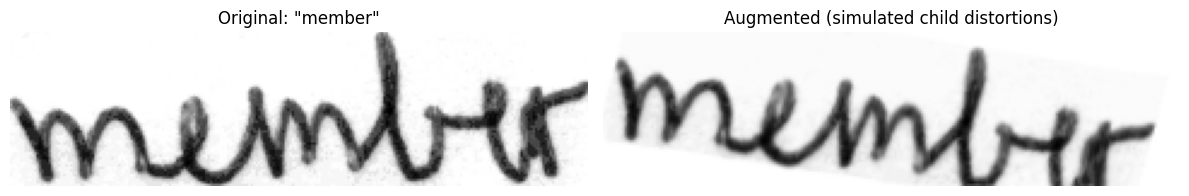

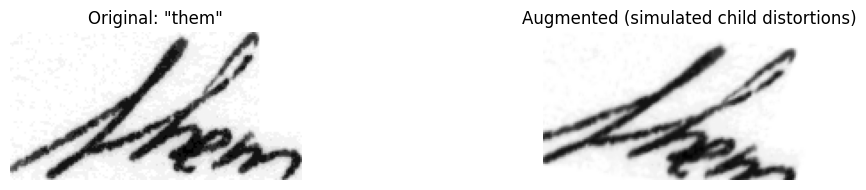

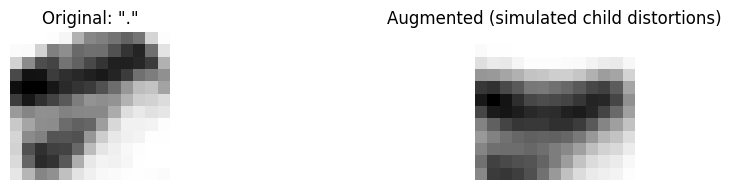

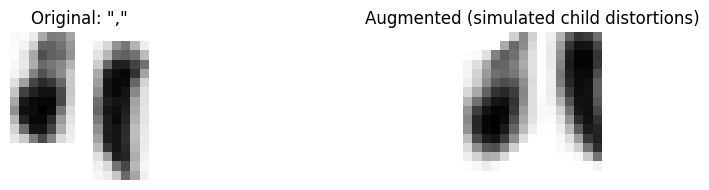

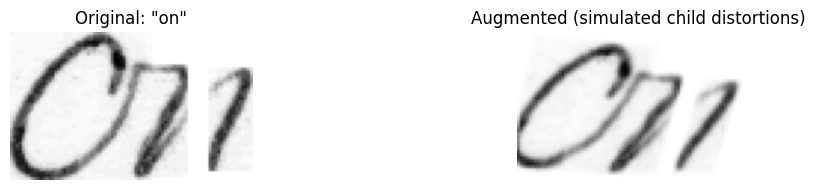

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from src.augmentation import ChildrenAugmentation

aug = ChildrenAugmentation(p=1.0, seed=42)  # p=1.0 to always show the effect
indices = np.random.choice(len(train_hf), 5, replace=False)

for idx in indices:
    sample = train_hf[int(idx)]
    img = sample['image']
    if img.mode != 'L':
        img = img.convert('L')
    img_np = np.array(img, dtype=np.uint8)
    augmented = aug(img_np)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 2))
    ax1.imshow(img_np, cmap='gray'); ax1.set_title(f'Original: "{sample["text"]}"'); ax1.axis('off')
    ax2.imshow(augmented, cmap='gray'); ax2.set_title('Augmented (simulated child distortions)'); ax2.axis('off')
    plt.tight_layout(); plt.show()

## 4. Build Advanced Model — STN-CRNN

Architecture: **STN (affine rectifier) → CNN → BiLSTM → CTC**. The STN is
initialised to the identity, so training starts from baseline behaviour and
only learns the geometric corrections it needs.

In [15]:
import torch
from src.model import CRNN

encoder = LabelEncoder()
model = CRNN(num_classes=len(encoder), use_stn=True)

total_params = sum(p.numel() for p in model.parameters())
stn_params = sum(p.numel() for p in model.stn.parameters())
print(f'Number of classes: {len(encoder)}')
print(f'Total parameters:  {total_params:,}  (STN adds {stn_params:,})')
print()
print('STN module:'); print(model.stn)

dummy = torch.randn(2, 1, 32, 128)
out = model(dummy)
print(f'\nInput shape:  {dummy.shape}')
print(f'Output shape: {out.shape}  (T={out.shape[0]}, B={out.shape[1]}, C={out.shape[2]})')

Number of classes: 53
Total parameters:  8,287,803  (STN adds 79,622)

STN module:
STN(
  (loc): Sequential(
    (0): Conv2d(1, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU(inplace=True)
    (6): AdaptiveAvgPool2d(output_size=(4, 8))
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=6, bias=True)
  )
)

Input shape:  torch.Size([2, 1, 32, 128])
Output shape: torch.Size([32, 2, 53])  (T=32, B=2, C=53)


## 5. Train STN-CRNN

Reuses the Milestone 1 training loop (`src/train.py`) unchanged; the config
flags `model.use_stn` and `data.augment` are the only differences. Early stops
on validation CER.

Using device: cuda
Train: 69190 samples
Val: 23064 samples
Model parameters: 8,287,803

Epoch 1/50


Validating: 100%|██████████| 361/361 [00:19<00:00, 18.98it/s]


Train Loss: 2.4518 | Val Loss: 1.7712 | CER: 0.4971 | WER: 0.7152
  -> New best CER: 0.4971

Epoch 2/50


Validating: 100%|██████████| 361/361 [00:18<00:00, 19.24it/s]


Train Loss: 1.3009 | Val Loss: 0.9468 | CER: 0.2547 | WER: 0.5145
  -> New best CER: 0.2547

Epoch 3/50


...

Train Loss: 0.1933 | Val Loss: 0.3813 | CER: 0.0871 | WER: 0.2019

Epoch 49/50


Validating: 100%|██████████| 361/361 [00:19<00:00, 18.75it/s]


Train Loss: 0.1947 | Val Loss: 0.3807 | CER: 0.0867 | WER: 0.2012
  -> New best CER: 0.0867

Epoch 50/50


Validating: 100%|██████████| 361/361 [00:18<00:00, 19.13it/s]


Train Loss: 0.1945 | Val Loss: 0.3812 | CER: 0.0872 | WER: 0.2022

Training complete. Best CER: 0.0867


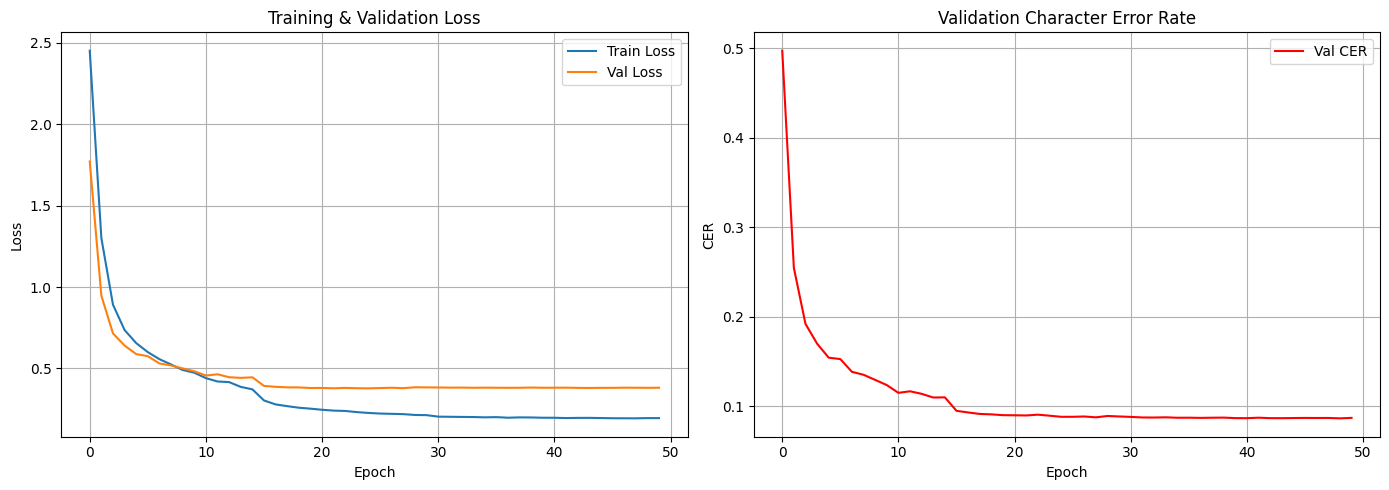

In [16]:
from src.train import train

results = train(CONFIG_PATH, checkpoint_dir='checkpoints_m2')

## 6. Results, STN Rectification & Sample Predictions

Best model from epoch 49
Best CER: 0.0867
Best WER: 0.2012


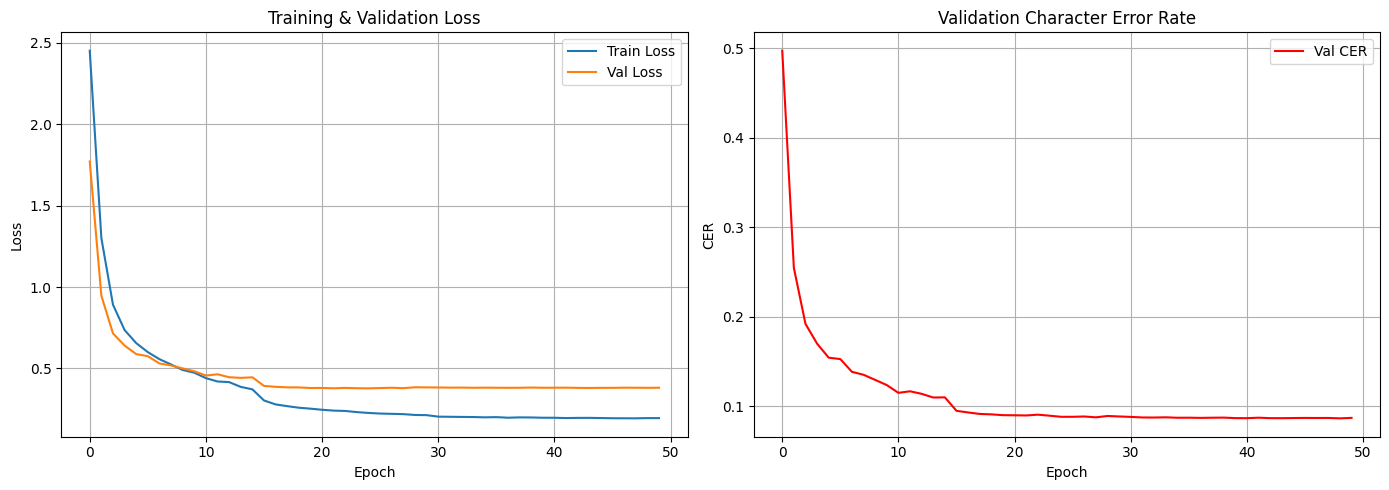

In [17]:
from src.utils import show_predictions, load_checkpoint, plot_training_curves
import yaml

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CRNN(num_classes=len(encoder), use_stn=True).to(device)
checkpoint = load_checkpoint('checkpoints_m2/best_model.pt', model)
print(f"Best model from epoch {checkpoint['epoch'] + 1}")
print(f"Best CER: {checkpoint['metrics']['cer']:.4f}")
print(f"Best WER: {checkpoint['metrics']['wer']:.4f}")

if results:
    plot_training_curves(results['train_losses'], results['val_losses'], results['val_cers'])

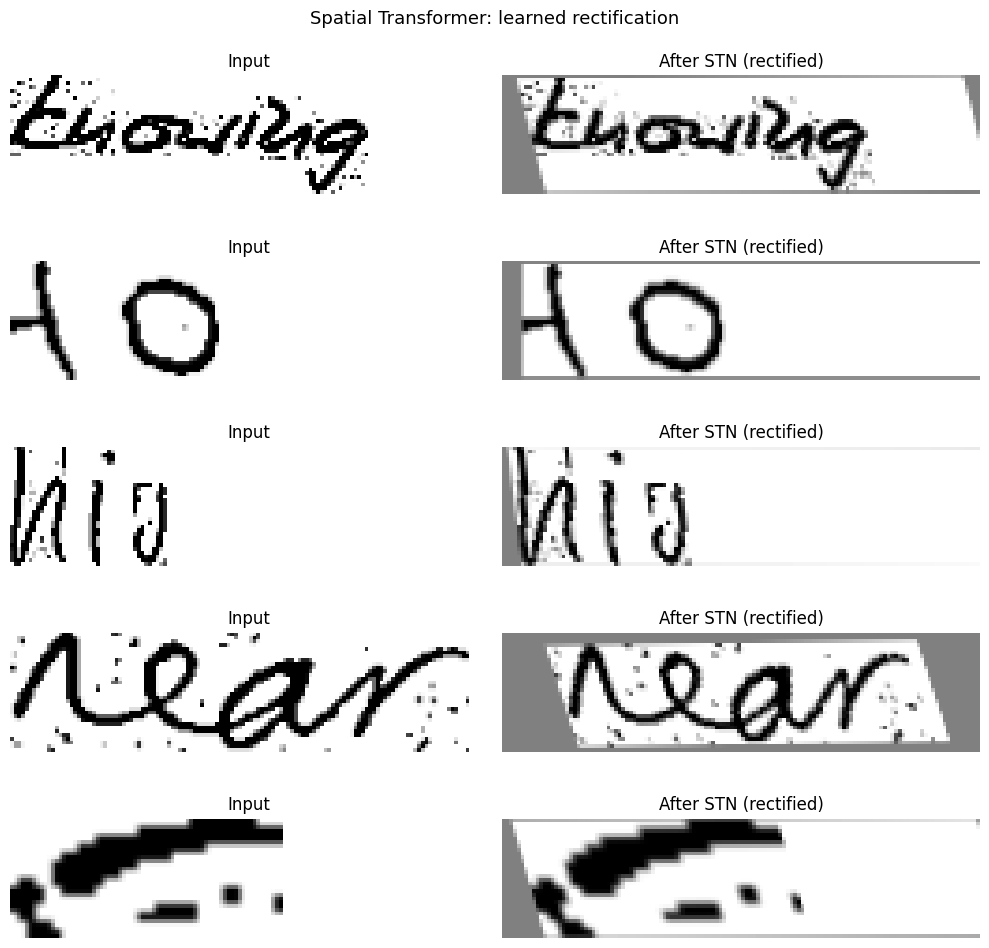

In [18]:
# Visualize what the STN learned: input image vs STN-rectified image.
from src.dataset import get_dataloaders

_, val_loader, _ = get_dataloaders(config, encoder)
model.eval()
images, *_ = next(iter(val_loader))
with torch.no_grad():
    rectified = model.stn(images.to(device)).cpu()

n = 5
fig, axes = plt.subplots(n, 2, figsize=(10, 2 * n))
for i in range(n):
    axes[i, 0].imshow((images[i, 0] * 0.5 + 0.5).numpy(), cmap='gray')
    axes[i, 0].set_title('Input'); axes[i, 0].axis('off')
    axes[i, 1].imshow((rectified[i, 0] * 0.5 + 0.5).numpy(), cmap='gray')
    axes[i, 1].set_title('After STN (rectified)'); axes[i, 1].axis('off')
plt.suptitle('Spatial Transformer: learned rectification', fontsize=13)
plt.tight_layout(); plt.show()

=== Sample Predictions (STN-CRNN) ===


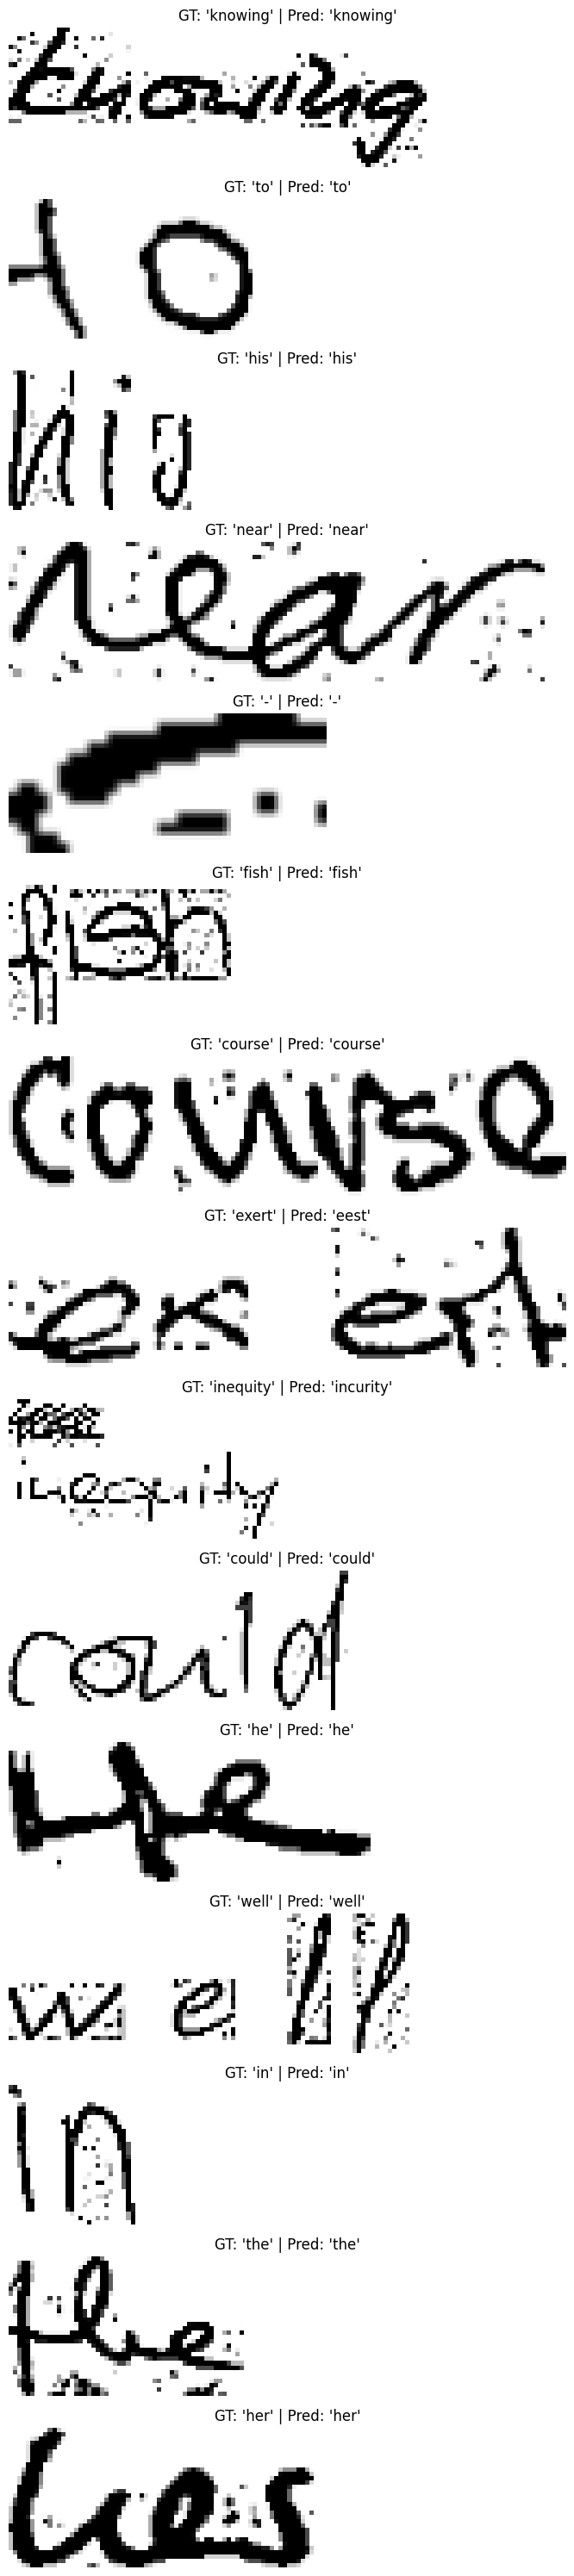

In [19]:
print('=== Sample Predictions (STN-CRNN) ===')
show_predictions(model, val_loader, encoder, device, n=15)

## 7. Error Analysis & Comparison vs. Baseline

Worst-CER cases plus overall stats, printed next to the Milestone 1 baseline
so the improvement (or regression) is explicit.

In [20]:
from src.metrics import compute_cer, evaluate_batch

model.eval()
all_predictions = []
with torch.no_grad():
    for images, labels, label_lengths, input_lengths in val_loader:
        images = images.to(device)
        log_probs = model(images)
        results_eval = evaluate_batch(log_probs.cpu(), labels, label_lengths, encoder)
        for pred, target in zip(results_eval['predictions'], results_eval['targets']):
            cer = compute_cer(pred, target)
            all_predictions.append((cer, pred, target))

all_predictions.sort(key=lambda x: x[0], reverse=True)

print('=== Worst 20 Predictions (highest CER) ===')
print(f'{"CER":>6} | {"Predicted":>20} | {"Ground Truth":>20}')
print('-' * 55)
for cer, pred, target in all_predictions[:20]:
    print(f'{cer:6.2f} | {pred:>20} | {target:>20}')

cers = [x[0] for x in all_predictions]
m2_mean, m2_median = np.mean(cers), np.median(cers)
m2_perfect = sum(1 for c in cers if c == 0)

# Milestone 1 baseline numbers (full run). Update BEST_CER/BEST_WER from M1 cell 9.
BASELINE = {'mean': 0.1066, 'median': 0.0000, 'perfect': 17387, 'total': 23064,
            'best_cer': 0.1065, 'best_wer': 0.2460}

print('\n=== M2 vs. Baseline (validation) ===')
print(f'{"Metric":<22}{"Baseline (M1)":>16}{"STN-CRNN (M2)":>16}')
print('-' * 54)
print(f'{"Mean CER":<22}{BASELINE["mean"]:>16.4f}{m2_mean:>16.4f}')
print(f'{"Median CER":<22}{BASELINE["median"]:>16.4f}{m2_median:>16.4f}')
print(f'{"Perfect (CER=0)":<22}{BASELINE["perfect"]:>16}{m2_perfect:>16}')
print(f'{"Samples":<22}{BASELINE["total"]:>16}{len(cers):>16}')

=== Worst 20 Predictions (highest CER) ===
   CER |            Predicted |         Ground Truth
-------------------------------------------------------
  7.00 |             morality |                    a
  5.00 |                shayh |                    )
  5.00 |                which |                    (
  5.00 |                aster |                    .
  4.50 |          wedominater |                   in
  4.00 |                 bers |                    )
  4.00 |                 youl |                    ?
  3.00 |                  wes |                    .
  3.00 |                  you |                    "
  3.00 |                  wve |                    .
  3.00 |                  aem |                    .
  3.00 |            howll-fen |                  mr.
  3.00 |                  who |                    .
  3.00 |                  frm |                    ,
  3.00 |                  you |                    "
  3.00 |                  all |                    )
